# **SUCH AN EASY TASK: DETECTING SARCASM IN TEXT**

**Authors**: Eloïse Delerue (*eloise.delerue@psl.eu*), Lucile Lapray (*lucile.lapray@psl.eu*) and Léna Rebours (*lena.rebours@psl.eu*)

**Date**: June 2026

**Context**: CPES 3 DAC, *Machine Learning for Text* course final assignment

# 1. Notebook initialisation

## 1. Library import

In [ ]:
# Computing libraries
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Significance libraries
from itertools import combinations
from sklearn.metrics import accuracy_score
from statsmodels.stats.multitest import multipletests

# Graphical libraries
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import matplotlib.patches as mpatches

# Modelling libraries
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, ParameterGrid, GridSearchCV, cross_validate
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Text processing librairies
from sentence_transformers import SentenceTransformer

## 1.2 Style harmonisation

In [ ]:
palette=["#a50000", "#8E063A", "#780a5a", "#eb3232", "#dc3566", "#c72e9e"]
sns.set_theme(style="darkgrid",
              palette=palette,
              context='paper')

# 2. Data exploration

## 2.1 Data import

In [ ]:
df = pd.read_csv("combined_sarcasm_dataset.csv")
df.head(5)

,id,text,label,source
0,0,"And in Thailand they eat monkey arms, fancy a ...",0,CSC
1,1,And what way is that?,1,CSC
2,2,Change the record,0,CSC
3,3,"Cool story Steve, change the record",1,CSC
4,4,Cool story bro,1,CSC


In [ ]:
df = df.dropna()

## 2.1 Data description

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16865 entries, 0 to 16865
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      16865 non-null  int64 
 1   text    16865 non-null  object
 2   label   16865 non-null  int64 
 3   source  16865 non-null  object
dtypes: int64(2), object(2)
memory usage: 658.8+ KB


In [ ]:
df['label_name'] = df['label'].map({0: 'not sarcastic', 1: 'sarcastic'})

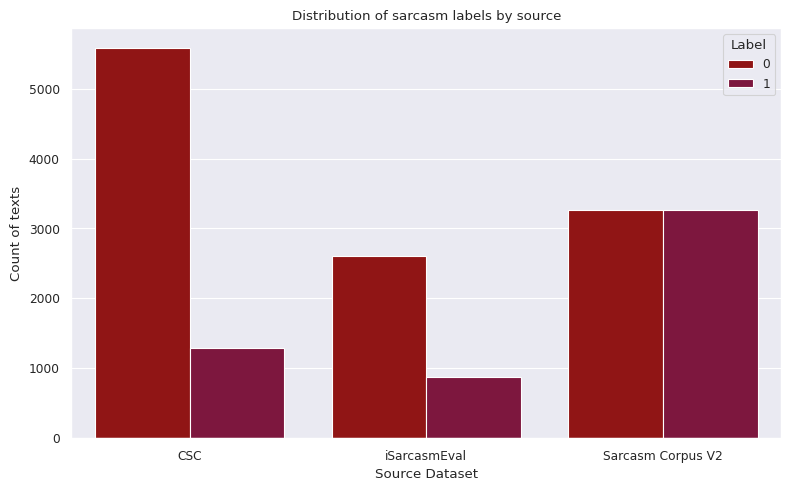

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='source', hue='label')

plt.title("Distribution of sarcasm labels by source")
plt.xlabel("Source Dataset")
plt.ylabel("Count of texts")
plt.legend(title="Label")

plt.tight_layout()
#plt.savefig("fig1.png")
plt.show()

# 3. Text processing

## 3.1 Count of words

In [ ]:
df['num_words'] = df['text'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)

## 3.2 General sentence embeddings

In [ ]:
model_st = SentenceTransformer('all-MiniLM-L6-v2')
global_embeddings = model_st.encode(df['text'].tolist(), convert_to_numpy=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
embeddings_df = pd.DataFrame(
    global_embeddings,
    columns=[f"emb_{i}" for i in range(global_embeddings.shape[1])],
    index=df.index
)
df = pd.concat([df, embeddings_df], axis=1)

## 3.3 Custom pivot embeddings

In [ ]:
def create_contrast_pivot_features(sentence, ratios, model):
    words = sentence.split()
    n_words = len(words)

    diff_vectors = []
    for ratio in ratios:
        if n_words < 2:
            return np.zeros(model.get_sentence_embedding_dimension())
        else:
            pivot = max(1, min(n_words - 1, int(n_words * ratio)))
            left_part = " ".join(words[:pivot])
            right_part = " ".join(words[pivot:])
            left_emb = model.encode(left_part, convert_to_numpy=True)
            right_emb = model.encode(right_part, convert_to_numpy=True)

        diff = right_emb - left_emb
        diff_vectors.append(diff)

    # Extraction of max values
    max_diff = np.max(diff_vectors, axis=0)
    return max_diff

## 3.4 Verification

In [ ]:
df.head(3)

,id,text,label,source,label_name,num_words,emb_0,emb_1,emb_2,emb_3,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
0,0,"And in Thailand they eat monkey arms, fancy a ...",0,CSC,not sarcastic,10,-0.002625,0.071777,0.029690,0.025728,...,-0.040867,-0.054362,0.018332,-0.072996,-0.012607,-0.015619,0.039937,-0.003511,0.026000,0.050281
1,1,And what way is that?,1,CSC,sarcastic,5,0.032711,0.039191,-0.020295,-0.016427,...,0.062206,0.061483,-0.042177,-0.049105,-0.068781,0.086030,0.038404,-0.010191,0.079729,-0.012915
2,2,Change the record,0,CSC,not sarcastic,3,-0.055744,0.084314,0.019317,-0.042236,...,0.034314,0.022460,0.055406,-0.029524,-0.073229,-0.011937,0.012493,-0.035224,-0.019133,0.035684


In [ ]:
df.describe()

,id,label,num_words,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
count,16865.000000,16865.000000,16865.000000,16865.000000,16865.000000,16865.000000,16865.000000,16865.000000,16865.000000,16865.000000,...,16865.000000,16865.000000,16865.000000,16865.000000,16865.000000,16865.000000,16865.000000,16865.000000,16865.000000,16865.000000
mean,8432.529202,0.321257,25.089594,-0.007260,0.002234,0.017589,0.000321,0.019779,-0.009184,0.026315,...,0.034506,-0.006467,-0.001628,0.006325,-0.016462,0.008509,0.043398,-0.015845,-0.006042,-0.002534
std,4869.082035,0.466973,25.605027,0.052625,0.053417,0.047675,0.045606,0.049714,0.046210,0.059060,...,0.048827,0.048134,0.040324,0.047758,0.049609,0.046177,0.048548,0.053903,0.060776,0.045278
min,0.000000,0.000000,1.000000,-0.208491,-0.247842,-0.154868,-0.173930,-0.205742,-0.164793,-0.222510,...,-0.182566,-0.181514,-0.181957,-0.172929,-0.219304,-0.172061,-0.155131,-0.216512,-0.222420,-0.181423
25%,4216.000000,0.000000,9.000000,-0.042752,-0.033309,-0.013910,-0.030494,-0.013441,-0.041021,-0.013859,...,0.002213,-0.038718,-0.028517,-0.025510,-0.049337,-0.021891,0.010429,-0.052430,-0.048503,-0.032537
50%,8433.000000,0.000000,16.000000,-0.007044,0.003640,0.018539,0.000021,0.020542,-0.010441,0.026445,...,0.035151,-0.006255,-0.001100,0.007111,-0.014954,0.009219,0.043082,-0.015721,-0.006172,-0.002455
75%,12649.000000,1.000000,30.000000,0.027993,0.038831,0.050448,0.030290,0.053951,0.021378,0.065452,...,0.067402,0.026221,0.025416,0.038965,0.017354,0.039958,0.076422,0.020422,0.034930,0.028025
max,16865.000000,1.000000,150.000000,0.223584,0.220862,0.206223,0.177077,0.210918,0.175467,0.230919,...,0.212978,0.178205,0.162027,0.178429,0.168730,0.181502,0.230208,0.203281,0.211019,0.178178


# 4. Modelling initialisation

## 4.1 Feature selection

In [ ]:
y = df['label'].values

In [ ]:
X = df.drop(columns=['id', 'label', 'source', 'label_name'])

## 4.2 Train/test split

In [ ]:
stratify_var = df['source'].astype(str) + "_" + df['label'].astype(str)

In [ ]:
X_train, X_test, y_train, y_test, stratify_train, stratify_test = train_test_split(
    X, y, stratify_var, test_size=0.2, random_state=42, stratify=stratify_var)

In [ ]:
X_train_baseline = X_train.drop(columns=['text'])
X_test_baseline = X_test.drop(columns=['text'])

## 4.3 Cross validation parameters

In [ ]:
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
outer_splits = list(cv.split(X_train, stratify_train))

## 4.4 Standardisation process

In [ ]:
numeric_features = ['num_words']
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'
)

## 4.5 Scores

In [ ]:
scoring = {'accuracy': 'accuracy',
           'precision': make_scorer(precision_score, zero_division=0),
           'recall': make_scorer(recall_score, zero_division=0),
           'f1': make_scorer(f1_score, zero_division=0)}

# 5. Logistic regression

## 5.1 Standardisation and training pipeline

In [ ]:
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(solver='saga', max_iter=1000, class_weight='balanced'))
])

## 5.2 Parameter grid

In [ ]:
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 5, 10, 50],
    'clf__penalty': ['l1', 'l2', None]
    }

In [ ]:
grid_search_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    cv=cv,
    scoring=scoring,
    refit='f1',
    n_jobs=-1
)

## 5.3 Model hyperparametrisation

In [ ]:
grid_search_lr.fit(X_train_baseline, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=7, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['num_words'])])),
                                       ('clf',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.01, 0.1, 1, 5, 10, 50],
                         'clf__penalty': ['l1', 'l2', None]},
             refit='f1',
             scoring={'accuracy': 'accuracy',
                      'f1': make_scorer(f1_score, response_method='predict', zero_division=0),
                      'precision': make_scorer(precision_score, response_method='predict', zero_division=0),
                      'recall': make_scorer(recall_score, response_method='predict', zero_division=0)})

In [ ]:
best_params_lr = grid_search_lr.best_params_
print(f"Best hyperparameters: {best_params_lr}")

Best hyperparameters: {'clf__C': 1, 'clf__penalty': 'l2'}


## 5.4 Model performance

In [ ]:
best_index_lr = grid_search_lr.best_index_

for metric in ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']:
    mean_val = grid_search_lr.cv_results_[f"mean_{metric}"][best_index_lr]
    std_val = grid_search_lr.cv_results_[f"std_{metric}"][best_index_lr]
    name = metric.replace('test_', '').capitalize()
    print(f"{name:<10}: {mean_val:.4f} ± {std_val:.4f}")

Accuracy  : 0.6964 ± 0.0098
Precision : 0.5212 ± 0.0113
Recall    : 0.6711 ± 0.0324
F1        : 0.5866 ± 0.0190


In [ ]:
y_train_pred_lr = cross_val_predict(
    estimator=grid_search_lr.best_estimator_,
    X=X_train_baseline,
    y=y_train,
    cv=cv,
    n_jobs=-1
)

cm_lr = confusion_matrix(y_train, y_train_pred_lr)
cm_lr_df = pd.DataFrame(cm_lr, index=['True Not sarcastic', 'True Sarcastic'], columns=['Predicted Not sarcastic', 'Predicted Sarcastic'])
display(cm_lr_df.style.set_caption("<b>Confusion matrix : Logistic regression (CV Train)</b>"))

,Predicted Not sarcastic,Predicted Sarcastic
True Not sarcastic,6487,2670
True Sarcastic,1426,2909


# 6. Neural network

## 6.1 Parameter grid

In [ ]:
ratio_grids = [
    [0.5],
    [0.3, 0.7],
    [0.3, 0.5, 0.7],
    [0.1, 0.5, 0.9]
]

In [ ]:
param_grid_nn = {
    'clf__hidden_layer_sizes': [(128, 64), (128, 64, 32), (256, 128), (256, 128, 64)],
    'clf__alpha': [0.0001, 0.001, 0.01],
    'clf__activation': ['relu']
}

## 6.2 Model hyperparametrisation

In [ ]:
all_fold_results = []

for ratios in ratio_grids:
    print(f"\nWorking on ratios: {ratios}")

    # Compute pivot embeddings
    diff_matrix = np.array([create_contrast_pivot_features(text, ratios=ratios, model=model_st) for text in X_train['text']])
    X_train_pivot = pd.DataFrame(diff_matrix, columns=[f"diff_{i}" for i in range(diff_matrix.shape[1])], index=X_train.index)
    X_train_pivot['num_words'] = X_train['num_words']

    pipeline_nn_pivot = Pipeline([
        ('preprocessor', preprocessor),
         ('clf', MLPClassifier(max_iter=500, early_stopping=True, random_state=42))])

    grid_search = GridSearchCV(pipeline_nn_pivot, param_grid_nn, cv=cv, scoring='f1', n_jobs=-1)

    # nested CV to test ratios
    cv_results_pivot = cross_validate(
        estimator=grid_search, X=X_train_pivot, y=y_train,
        cv=outer_splits, scoring=scoring, n_jobs=-1, return_estimator=True
    )

    # save metrics and params
    for i, model in enumerate(cv_results_pivot['estimator']):
        best_idx = model.best_index_

        result_entry = {
            'ratios': tuple(ratios),
            'params': tuple(sorted(model.best_params_.items())),
            'fold': i + 1,
            'f1': model.cv_results_['mean_test_score'][best_idx]
        }
        for metric in ['accuracy', 'precision', 'recall']:
            result_entry[metric] = cv_results_pivot[f'test_{metric}'][i]

        all_fold_results.append(result_entry)


Working on ratios: [0.5]


/tmp/ipykernel_464/3825772643.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  return np.zeros(model.get_sentence_embedding_dimension())
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Working on ratios: [0.3, 0.7]


/tmp/ipykernel_464/3825772643.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  return np.zeros(model.get_sentence_embedding_dimension())


## 6.3 Best hyperparameters

In [ ]:
df_pivot = pd.DataFrame(all_fold_results)
stats_pivot = df_pivot.groupby(['ratios', 'params'])['f1'].agg(['mean', 'count']).reset_index()

best_row = stats_pivot.sort_values(by=['mean', 'count'], ascending=False).iloc[0]
best_ratios = best_row['ratios']
best_params_nn_pivot = dict(best_row['params'])

print(f"Best config: Ratios {list(best_ratios)} | Params {best_params_nn_pivot}")
print(f"Mean F1-score : {best_row['mean']:.4f}")
print(f"Best on {int(best_row['count'])} folds")

## 6.4 Loss curves

In [ ]:
target_params = tuple(sorted(best_params_nn_pivot.items()))

best_models = []
for res in cv_results_pivot['estimator']:
    if tuple(sorted(res.best_params_.items())) == target_params:
        best_models.append(res.best_estimator_.named_steps['clf'])

In [ ]:
plt.figure(figsize=(8, 5))
for i, clf in enumerate(best_models):
    plt.plot(clf.loss_curve_, label=f"Fold correspondant {i+1}")

plt.title(f"Loss Curves (Config: Ratios {list(best_ratios)})")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 6.5 Confusion matrix

In [ ]:
clean_params = {k.replace('clf__', ''): v for k, v in best_params_nn_pivot.items()}

best_nn_pivot = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(**clean_params, max_iter=500, early_stopping=True, random_state=42))
])

In [ ]:
X_final_pivot = pd.DataFrame(np.array([create_contrast_pivot_features(t, ratios=list(best_ratios), model=model_st) for t in X_train['text']]), index=X_train.index)
X_final_pivot['num_words'] = X_train['num_words']

In [ ]:
X_final_pivot.columns = X_final_pivot.columns.astype(str)
best_nn_pivot.fit(X_final_pivot, y_train)
y_train_pred_pivot = best_nn_pivot.predict(X_final_pivot)

In [ ]:
cm_pivot = confusion_matrix(y_train, y_train_pred_pivot)
cm_pivot_df = pd.DataFrame(cm_pivot, index=['Not Sarcastic', 'Sarcastic'], columns=['Not Sarcastic', 'Sarcastic'])
cm_pivot_df.index.name = 'True Labels'; cm_pivot_df.columns.name = 'Predictions'
display(cm_pivot_df)

## 6.6 Performance

In [ ]:
best_config_data = [
    res for res in all_fold_results
    if res['ratios'] == tuple(best_ratios) and dict(res['params']) == best_params_nn_pivot
]

In [ ]:
metrics = ['f1', 'accuracy', 'precision', 'recall']

for m in metrics:
    values = [res[m] for res in best_config_data]
    mean_val = np.mean(values)
    std_val = np.std(values)
    print(f"{m.capitalize():<10}: {mean_val:.4f} ± {std_val:.4f}")

# 7. Neural network baseline

## 7.1 Model training

In [ ]:
pipeline_nn_baseline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(max_iter=500, early_stopping=True, random_state=42))
])

In [ ]:
pipeline_nn_baseline.set_params(**best_params_nn_pivot)

cv_results_nn_baseline = cross_validate(
    estimator=pipeline_nn_baseline,
    X=X_train_baseline,
    y=y_train,
    cv=outer_splits,
    scoring=scoring,
    n_jobs=-1,
    return_estimator=True,
    return_indices=True
)

## 7.2 Model performance

In [ ]:
for metric in ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']:
    mean_val = np.mean(cv_results_nn_baseline[metric])
    std_val = np.std(cv_results_nn_baseline[metric])
    name = metric.replace('test_', '').capitalize()
    print(f"{name:<10}: {mean_val:.4f} ± {std_val:.4f}")

# 8. Models comparison

In [ ]:
# Compute pivot embeddings for X_train
diff_matrix_train = np.array([
    create_contrast_pivot_features(text, ratios=best_ratios, model=model_st)
    for text in X_train['text']])

diff_columns = [f"diff_{i}" for i in range(diff_matrix_train.shape[1])]
X_train_pivot = pd.DataFrame(diff_matrix_train, columns=diff_columns, index=X_train.index)
X_train_pivot['num_words'] = X_train['num_words']

# Compute pivot embeddings for X_test
diff_matrix_test = np.array([
    create_contrast_pivot_features(text, ratios=best_ratios, model=model_st)
    for text in X_test['text']])

X_test_pivot = pd.DataFrame(diff_matrix_test, columns=diff_columns, index=X_test.index)
X_test_pivot['num_words'] = X_test['num_words']

## 8.1 Fitting & predicting

In [ ]:
pipeline_lr.set_params(**best_params_lr).fit(X_train_baseline, y_train)

In [ ]:
y_pred_lr = pipeline_lr.predict(X_test_baseline)

In [ ]:
pipeline_nn_baseline.set_params(**best_params_nn_pivot).fit(X_train_baseline, y_train)

In [ ]:
y_pred_nn_baseline = pipeline_nn_baseline.predict(X_test_baseline)

In [ ]:
pipeline_nn_pivot.set_params(**best_params_nn_pivot).fit(X_train_pivot, y_train)

In [ ]:
y_pred_nn_pivot = pipeline_nn_pivot.predict(X_test_pivot)

## 8.2 Confusion matrices

In [ ]:
def create_cm_dataframe(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm,
                         index=['True Not Sarcastic', 'True Sarcastic'],
                         columns=['Predicted Not Sarcastic', 'Predicted Sarcastic'])
    return df_cm.style.set_caption(f"<b>Confusion matrix: {model_name}</b>")

In [ ]:
cm_table_lr = create_cm_dataframe(y_test, y_pred_lr, "Régression Logistique")
display(cm_table_lr)

,Predicted Not Sarcastic,Predicted Sarcastic
True Not Sarcastic,6,8
True Sarcastic,3,3


In [ ]:
cm_table_nn_baseline = create_cm_dataframe(y_test, y_pred_nn_baseline, "NN Baseline")
display(cm_table_nn_baseline)

,Predicted Not Sarcastic,Predicted Sarcastic
True Not Sarcastic,14,0
True Sarcastic,5,1


In [ ]:
cm_table_nn_pivot = create_cm_dataframe(y_test, y_pred_nn_pivot, "NN avec Pivot Embeddings")
display(cm_table_nn_pivot)

,Predicted Not Sarcastic,Predicted Sarcastic
True Not Sarcastic,7,7
True Sarcastic,4,2


## 8.3 Visualisation

In [ ]:
models_preds = {
    "LR": y_pred_lr,
    "NN Baseline": y_pred_nn_baseline,
    "NN Pivot": y_pred_nn_pivot
}

In [ ]:
metrics = {
    "Accuracy": accuracy_score,
    "F1-Score": f1_score,
    "Precision": precision_score,
    "Recall": recall_score
}

In [ ]:
results = []
for model_name, y_pred in models_preds.items():
    for metric_name, metric_func in metrics.items():
        score = metric_func(y_test, y_pred)
        results.append({"Model": model_name, "Metric": metric_name, "Score": score})

df_results = pd.DataFrame(results)

/tmp/ipykernel_7252/2213774852.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results[df_results['Metric'] == metric],
/tmp/ipykernel_7252/2213774852.py:7: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.barplot(data=df_results[df_results['Metric'] == metric],
/tmp/ipykernel_7252/2213774852.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results[df_results['Metric'] == metric],
/tmp/ipykernel_7252/2213774852.py:7: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.barplot(data=df_results[df_results['Metric'] == metric],
/tmp/ipykernel_7252/2213774852.py:7: FutureWar

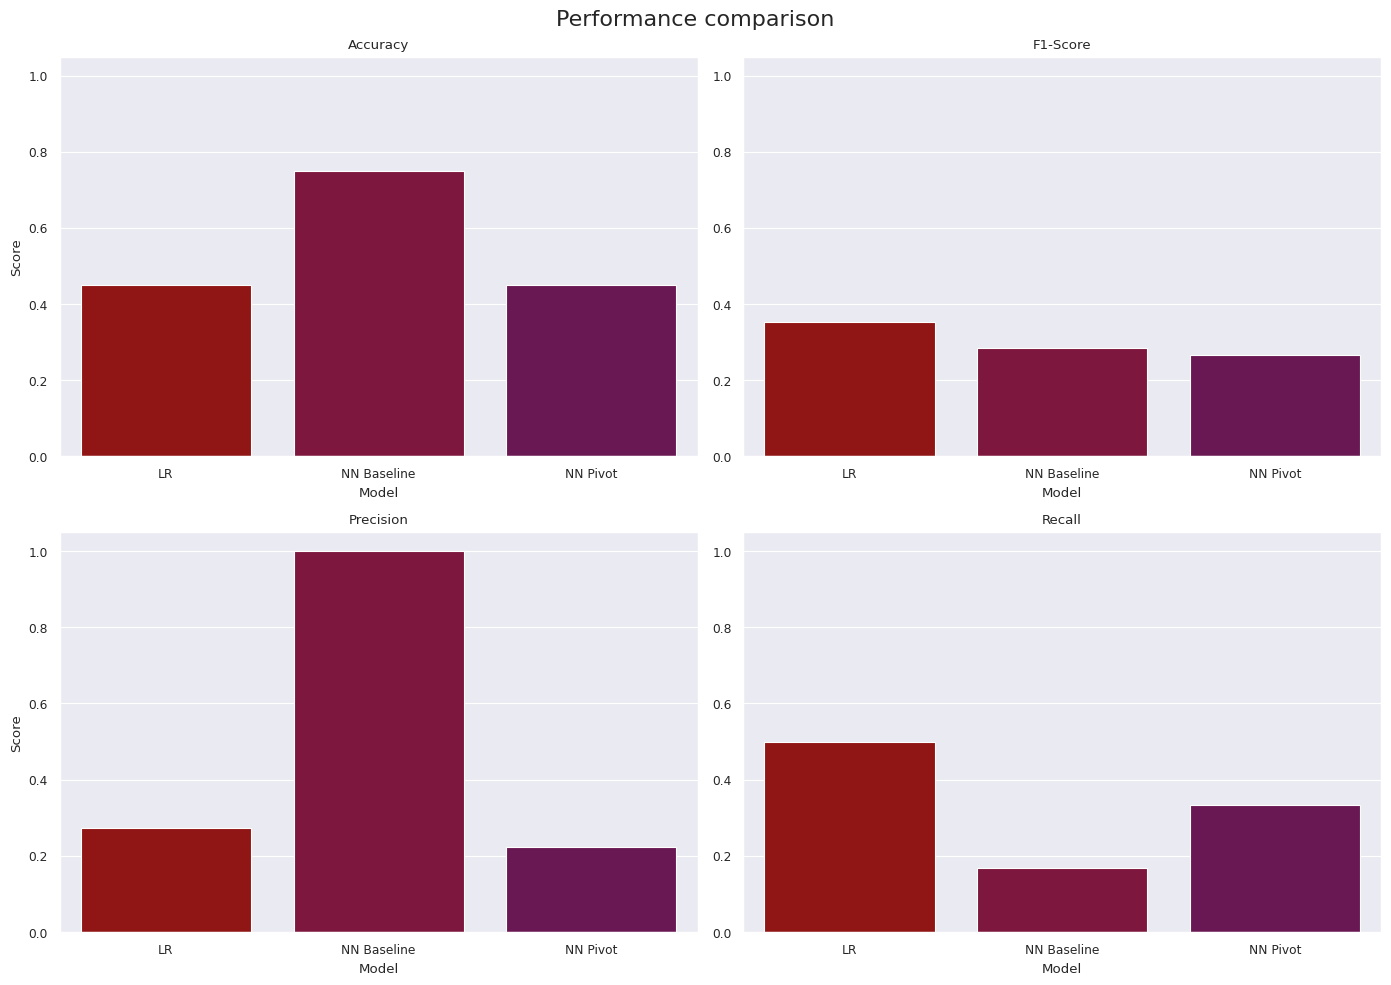

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Performance comparison', fontsize=16)

axes = axes.flatten()

for i, metric in enumerate(metrics.keys()):
    sns.barplot(data=df_results[df_results['Metric'] == metric],
                x='Model', y='Score', ax=axes[i], palette=palette)
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1.05)
    axes[i].set_ylabel('Score' if i % 2 == 0 else '')

plt.tight_layout()
plt.show()

## 8.4 Significativity test

Léna it's your time to shine code moi ça à la M. Propre bébé

In [ ]:
df_preds = pd.DataFrame({
    'lr_pred': y_pred_lr,
    'nn_baseline_pred': y_pred_nn_baseline,
    'nn_pivot_pred': y_pred_nn_pivot,
    'ground_truth': np.array(y_test)
})

df_preds = df_preds[['lr_pred', 'nn_baseline_pred', 'nn_pivot_pred', 'ground_truth']]
display(df_preds)

,lr_pred,nn_baseline_pred,nn_pivot_pred,ground_truth
0,1,0,1,0
1,0,0,1,0
2,0,1,0,1
3,1,0,0,1
4,1,0,0,0
5,1,0,0,0
6,0,0,1,0
7,1,0,0,0
8,1,0,1,0
9,0,0,1,0


In [ ]:
# ==========================================================
# Paired Monte Carlo permutation test
# ==========================================================

def paired_mc_permutation_test(
    y_true,
    pred_a,
    pred_b,
    R=10000,
    random_state=42
):

    rng = np.random.default_rng(random_state)

    observed = (
        f1_score(y_true, pred_a)
        - f1_score(y_true, pred_b)
    )

    count = 0
    n = len(y_true)

    for _ in range(R):

        swap = rng.random(n) < 0.5

        perm_a = pred_a.copy()
        perm_b = pred_b.copy()

        perm_a[swap], perm_b[swap] = (
            perm_b[swap],
            perm_a[swap]
        )

        diff = (
            f1_score(y_true, perm_a)
            - f1_score(y_true, perm_b)
        )

        if abs(diff) >= abs(observed):
            count += 1

    p_value = (count + 1) / (R + 1)

    return observed, p_value


# ==========================================================
# Pairwise comparisons
# ==========================================================

models = {
    "Logistic Regression": df_preds["lr_pred"].values,
    "NN Baseline": df_preds["nn_baseline_pred"].values,
    "NN Pivot": df_preds["nn_pivot_pred"].values
}

y_true = df_preds["ground_truth"].values

results = []
raw_pvalues = []

for model_a, model_b in combinations(models.keys(), 2):

    pred_a = models[model_a]
    pred_b = models[model_b]

    diff, p = paired_mc_permutation_test(
        y_true,
        pred_a,
        pred_b,
        R=10000,
        random_state=42
    )

    raw_pvalues.append(p)

    results.append({
        "comparison": f"{model_a} vs {model_b}",
        "f1_A": f1_score(y_true, pred_a),
        "f1_B": f1_score(y_true, pred_b),
        "delta_f1": diff,
        "p_raw": p
    })

# ==========================================================
# Benjamini-Hochberg correction
# ==========================================================

_, p_bh, _, _ = multipletests(
    raw_pvalues,
    method="fdr_bh"
)

for i in range(len(results)):

    results[i]["p_BH"] = p_bh[i]

    if p_bh[i] < 0.001:
        results[i]["stars"] = "***"
    elif p_bh[i] < 0.01:
        results[i]["stars"] = "**"
    elif p_bh[i] < 0.05:
        results[i]["stars"] = "*"
    else:
        results[i]["stars"] = "ns"

In [ ]:
# On save les résultats si jamais

results_df = pd.DataFrame(results)

results_df.to_csv(
    "permutation_test_accuracy_BH.csv",
    index=False
)

print(results_df)

print(
    "\nResults saved to: permutation_test_accuracy_BH.csv"
)

### 8.5. Significance plots

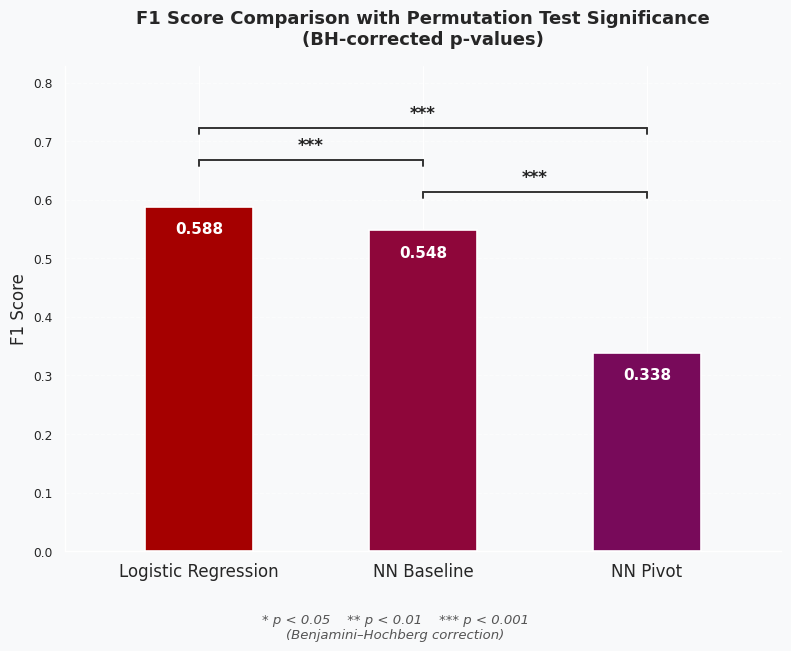

In [6]:
# data
df = pd.read_csv('permutation_test_accuracy_BH.csv')

models = ['Logistic Regression', 'NN Baseline', 'NN Pivot']
f1_scores = {
    'Logistic Regression': df.loc[df['comparison'].str.startswith('Logistic'), 'f1_A'].iloc[0],
    'NN Baseline':         df.loc[df['comparison'].str.contains('NN Baseline vs'), 'f1_A'].iloc[0],
    'NN Pivot':            df.loc[df['comparison'].str.contains('NN Pivot'), 'f1_B'].iloc[0],
}

# Map comparison = (model_A_idx, model_B_idx, stars)
comparisons = [
    (0, 1, df.loc[0, 'stars']),  # LR vs NN Baseline
    (0, 2, df.loc[1, 'stars']),  # LR vs NN Pivot
    (1, 2, df.loc[2, 'stars']),  # NN Baseline vs NN Pivot
]

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

x = np.arange(len(models))
bar_w = 0.48
colors = ['#4C72B0', '#DD8452', '#55A868']

bars = ax.bar(
    x,
    [f1_scores[m] for m in models],
    width=bar_w,
    zorder=3,
    edgecolor='white',
    linewidth=1.2,
    color=sns.color_palette()[:3]
)

# Value labels inside bars
for bar, m in zip(bars, models):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 0.025,
            f'{f1_scores[m]:.3f}',
            ha='center', va='top',
            fontsize=11, fontweight='bold', color='white')

# Heights at which brackets sit (stacked so they don't overlap)
bracket_gap  = 0.015   # gap between bar top and bracket foot
level_step   = 0.055   # vertical spacing between bracket levels
text_offset  = 0.010   # stars sit just above the horizontal bar

# Assign levels: widest span (0-2) at top, others below
level_order = [(0, 2), (0, 1), (1, 2)]
level_map   = {pair: i for i, pair in enumerate(reversed(level_order))}

max_bar = max(f1_scores.values())
base_y  = max_bar + bracket_gap

for (i, j, stars) in comparisons:
    lvl  = level_map[(i, j)]
    y    = base_y + lvl * level_step
    xi   = x[i]
    xj   = x[j]

    # Vertical feet
    ax.plot([xi, xi], [y, y + 0.01], color='#333333', lw=1.4, clip_on=False)
    ax.plot([xj, xj], [y, y + 0.01], color='#333333', lw=1.4, clip_on=False)
    # Horizontal bar
    ax.plot([xi, xj],  [y + 0.01, y + 0.01], color='#333333', lw=1.4, clip_on=False)
    # Stars
    ax.text((xi + xj) / 2, y + 0.01 + text_offset, stars,
            ha='center', va='bottom', fontsize=12, color='#222222',
            fontweight='bold')

# axes
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score Comparison with Permutation Test Significance\n(BH-corrected p-values)',
             fontsize=13, fontweight='bold', pad=16)

top_y = base_y + len(comparisons) * level_step + 0.06
ax.set_ylim(0, top_y)
ax.set_xlim(-0.6, len(models) - 0.4)

ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

legend_text = ('* p < 0.05    ** p < 0.01    *** p < 0.001\n'
               '(Benjamini–Hochberg correction)')
fig.text(0.5, -0.03, legend_text, ha='center', va='top',
         fontsize=9.5, color='#555555', style='italic')

plt.tight_layout()